# Notebook 5 — Efecto de la explotación sobre las lesiones de TB
### Análisis descriptivo y estadístico (sin modelos)

**Pregunta de investigación:** ¿Difiere la prevalencia, la gravedad y el patrón de las
lesiones tuberculosas entre las cuatro explotaciones estudiadas?

| Variable de lesión | Tipo | Test principal |
|---|---|---|
| `Lesiones_TB` | Binaria (0/1) | Chi-cuadrado / Fisher exacto + IC Wilson |
| `Score_lesional` | Ordinal (0–5) | Kruskal-Wallis + Dunn post-hoc |
| `Patron_lesiones` | Binaria (0=focal, 1=generalizado) — solo TB+ | Fisher exacto |
| `IDTC` | Continua (≥0) | Kruskal-Wallis + Dunn post-hoc |

> **Enfoque exclusivamente descriptivo:** se reportan prevalencias, medianas [IQR],
> intervalos de confianza y p-valores de tests no paramétricos. No se ajustan modelos
> predictivos ni se controlan covariables.

## 1. Setup e importaciones

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import (
    kruskal, chi2_contingency, fisher_exact, mannwhitneyu, spearmanr
)
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from itertools import combinations
import tb_utils as tb

PALETTE = tb.set_plot_style()
tb.set_seeds(tb.SEED)

DATA = "../BD.csv"
df = tb.clean(tb.load_raw(DATA))

EXPLOTS = sorted(df[tb.GROUP_COL].unique())
EXPL_COLORS = dict(zip(EXPLOTS, PALETTE[:len(EXPLOTS)]))

print(f"Dataset: n={len(df)}, explotaciones={EXPLOTS}")
print(f"Prevalencia global Lesiones_TB: {df['Lesiones_TB'].mean():.3f}")

Dataset: n=106, explotaciones=['VA32D', 'VC30D', 'VC94C', 'WZ72B']
Prevalencia global Lesiones_TB: 0.613


## 2. Resumen general por explotación

In [2]:
rows = []
for granja in EXPLOTS:
    g = df[df[tb.GROUP_COL] == granja]
    n = len(g)
    n_pos = int(g["Lesiones_TB"].sum())
    prev = n_pos / n
    ci_lo, ci_hi = proportion_confint(n_pos, n, alpha=0.05, method="wilson")
    sl_med = g["Score_lesional"].median()
    sl_q1  = g["Score_lesional"].quantile(0.25)
    sl_q3  = g["Score_lesional"].quantile(0.75)
    idtc_med = g["IDTC"].median()
    idtc_q1  = g["IDTC"].quantile(0.25)
    idtc_q3  = g["IDTC"].quantile(0.75)
    rows.append({
        "Explotación": granja,
        "n": n,
        "TB+ (n)": n_pos,
        "Prevalencia": f"{prev:.1%}",
        "IC 95% (Wilson)": f"[{ci_lo:.1%}, {ci_hi:.1%}]",
        "Score (med [IQR])": f"{sl_med:.1f} [{sl_q1:.1f}–{sl_q3:.1f}]",
        "IDTC (med [IQR])": f"{idtc_med:.1f} [{idtc_q1:.1f}–{idtc_q3:.1f}]",
    })

overview = pd.DataFrame(rows)
print("Tabla resumen general por explotación:")
display(overview)

Tabla resumen general por explotación:


,Explotación,n,TB+ (n),Prevalencia,IC 95% (Wilson),Score (med [IQR]),IDTC (med [IQR])
0,VA32D,21,8,38.1%,"[20.8%, 59.1%]",0.0 [0.0–2.0],13.0 [10.0–17.0]
1,VC30D,55,32,58.2%,"[45.0%, 70.3%]",1.0 [0.0–2.0],10.0 [6.0–13.5]
2,VC94C,16,15,93.8%,"[71.7%, 98.9%]",5.0 [5.0–5.0],7.0 [5.0–10.2]
3,WZ72B,14,10,71.4%,"[45.4%, 88.3%]",1.0 [0.2–1.0],11.5 [9.0–14.0]


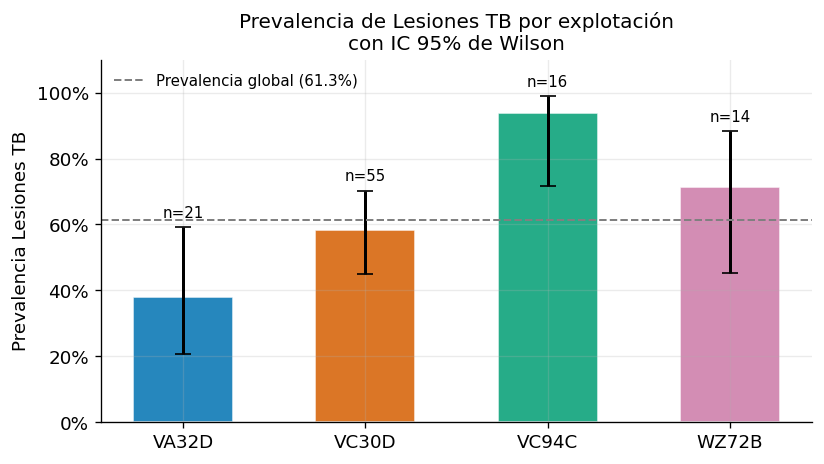

In [3]:
# Figura de prevalencias con IC
prevs, ci_los, ci_his, ns = [], [], [], []
for granja in EXPLOTS:
    g = df[df[tb.GROUP_COL] == granja]
    n = len(g); n_pos = int(g["Lesiones_TB"].sum())
    lo, hi = proportion_confint(n_pos, n, alpha=0.05, method="wilson")
    prevs.append(n_pos / n); ci_los.append(lo); ci_his.append(hi); ns.append(n)

fig, ax = plt.subplots(figsize=(7, 4))
colors = [EXPL_COLORS[g] for g in EXPLOTS]
bars = ax.bar(EXPLOTS, prevs, color=colors, alpha=0.85, edgecolor="white", width=0.55)
for i, (lo, hi, p, n) in enumerate(zip(ci_los, ci_his, prevs, ns)):
    ax.errorbar(EXPLOTS[i], p, yerr=[[p - lo], [hi - p]],
                fmt="none", color="black", capsize=5, lw=1.8)
    ax.text(i, hi + 0.03, f"n={n}", ha="center", fontsize=9)

prev_global = df["Lesiones_TB"].mean()
ax.axhline(prev_global, ls="--", color="grey", lw=1.2, label=f"Prevalencia global ({prev_global:.1%})")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Prevalencia Lesiones TB")
ax.set_title("Prevalencia de Lesiones TB por explotación\ncon IC 95% de Wilson")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.savefig("figures/fig_05_prevalencia_por_explotacion.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Lesiones_TB vs Explotación — test de homogeneidad

Pregunta: ¿son las prevalencias de lesión TB estadísticamente distintas entre explotaciones?

- **Test global:** Chi-cuadrado de Pearson (tabla 4×2) si todos los esperados ≥ 5,
  sino test exacto de Freeman-Halton.
- **Comparaciones pareadas:** test exacto de Fisher con corrección de Bonferroni.

In [4]:
# Tabla de contingencia 4×2
cont_tb = pd.crosstab(df[tb.GROUP_COL], df["Lesiones_TB"])
cont_tb.columns = ["TB−", "TB+"]
print("Tabla de contingencia Expl × Lesiones_TB:")
display(cont_tb)

chi2, p_chi2, dof, expected = chi2_contingency(cont_tb)
min_expected = expected.min()
print(f"\nChi-cuadrado (global):")
print(f"  χ²({dof}) = {chi2:.3f}, p = {p_chi2:.4f}")
print(f"  Frecuencias esperadas mínimas = {min_expected:.2f}")
if min_expected < 5:
    print("  ⚠ Alguna celda esperada < 5 — interpretar con cautela.")
else:
    print("  ✓ Todas las celdas esperadas ≥ 5.")

Tabla de contingencia Expl × Lesiones_TB:


,TB−,TB+
Expl,,
VA32D,13,8
VC30D,23,32
VC94C,1,15
WZ72B,4,10



Chi-cuadrado (global):
  χ²(3) = 12.702, p = 0.0053
  Frecuencias esperadas mínimas = 5.42
  ✓ Todas las celdas esperadas ≥ 5.


In [5]:
# Comparaciones pareadas con Fisher exacto + corrección de Bonferroni
pairs = list(combinations(EXPLOTS, 2))
n_tests = len(pairs)
rows_pw = []
for a, b in pairs:
    sub = df[df[tb.GROUP_COL].isin([a, b])]
    ct = pd.crosstab(sub[tb.GROUP_COL], sub["Lesiones_TB"]).reindex([a, b])
    # Asegurar columnas 0 y 1
    for col in [0, 1]:
        if col not in ct.columns:
            ct[col] = 0
    ct = ct[[0, 1]]
    table_2x2 = ct.values
    _, p = fisher_exact(table_2x2)
    p_bonf = min(p * n_tests, 1.0)
    prev_a = df[df[tb.GROUP_COL] == a]["Lesiones_TB"].mean()
    prev_b = df[df[tb.GROUP_COL] == b]["Lesiones_TB"].mean()
    rows_pw.append({
        "Expl A": a, "Prev A": f"{prev_a:.1%}",
        "Expl B": b, "Prev B": f"{prev_b:.1%}",
        "p (Fisher)": round(p, 4),
        "p (Bonferroni)": round(p_bonf, 4),
        "Sig.": "*" if p_bonf < 0.05 else "",
    })

pw_df = pd.DataFrame(rows_pw)
print(f"Comparaciones pareadas (Fisher exacto, Bonferroni n={n_tests}):")
display(pw_df)

Comparaciones pareadas (Fisher exacto, Bonferroni n=6):


,Expl A,Prev A,Expl B,Prev B,p (Fisher),p (Bonferroni),Sig.
0,VA32D,38.1%,VC30D,58.2%,0.1320,0.7921,
1,VA32D,38.1%,VC94C,93.8%,0.0006,0.0037,*
2,VA32D,38.1%,WZ72B,71.4%,0.0858,0.5148,
3,VC30D,58.2%,VC94C,93.8%,0.0075,0.0448,*
4,VC30D,58.2%,WZ72B,71.4%,0.5412,1.0000,
5,VC94C,93.8%,WZ72B,71.4%,0.1571,0.9425,


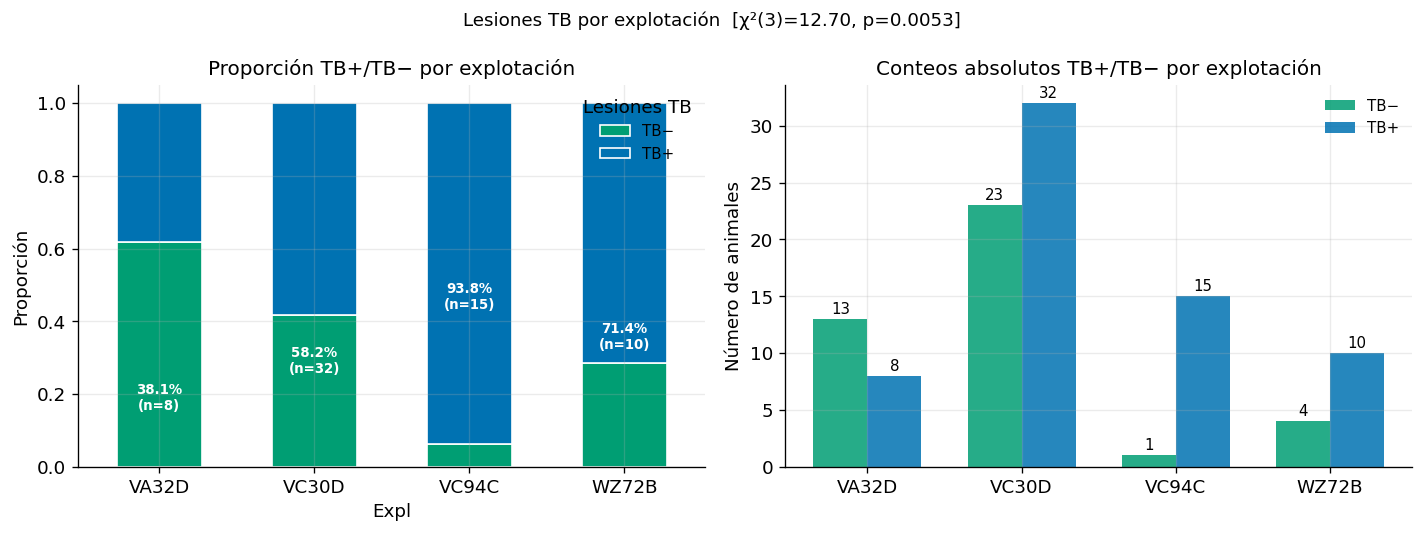

In [6]:
# Gráfico de barras apiladas (proporcional)
prop_df = cont_tb.div(cont_tb.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Barras apiladas proporcionales
ax = axes[0]
prop_df.plot(kind="bar", stacked=True, ax=ax,
             color=[PALETTE[2], PALETTE[0]], edgecolor="white", width=0.55)
ax.set_ylabel("Proporción")
ax.set_title("Proporción TB+/TB− por explotación")
ax.set_xticklabels(EXPLOTS, rotation=0)
ax.legend(["TB−", "TB+"], title="Lesiones TB", fontsize=9)
for i, granja in enumerate(EXPLOTS):
    p_pos = prop_df.loc[granja, "TB+"]
    n = cont_tb.loc[granja].sum()
    ax.text(i, p_pos / 2, f"{p_pos:.1%}\n(n={cont_tb.loc[granja,'TB+']})",
            ha="center", va="center", fontsize=8, color="white", fontweight="bold")

# Conteos absolutos
ax2 = axes[1]
x = np.arange(len(EXPLOTS))
width = 0.35
b1 = ax2.bar(x - width/2, cont_tb["TB−"], width, label="TB−", color=PALETTE[2], alpha=0.85)
b2 = ax2.bar(x + width/2, cont_tb["TB+"], width, label="TB+", color=PALETTE[0], alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(EXPLOTS)
ax2.set_ylabel("Número de animales")
ax2.set_title("Conteos absolutos TB+/TB− por explotación")
ax2.legend(fontsize=9)
for bar in [*b1, *b2]:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.2, str(int(h)),
             ha="center", va="bottom", fontsize=9)

plt.suptitle(f"Lesiones TB por explotación  [χ²({dof})={chi2:.2f}, p={p_chi2:.4f}]", fontsize=11)
plt.tight_layout()
plt.savefig("figures/fig_05_lesiones_tb_por_explotacion.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Score lesional por explotación

El score lesional es ordinal (0–5). Se usa Kruskal-Wallis (no paramétrico) y,
si es significativo, test de Dunn con corrección de Bonferroni para identificar
qué pares de explotaciones difieren.

> Nota: el score es 0 en animales sin lesión (TB−), por lo que el análisis global
> refleja tanto la prevalencia como la gravedad. Se muestra también restringido
> a animales TB+ para separar ambos efectos.

In [7]:
# Descriptivos del score por explotación (todos los animales)
score_desc = df.groupby(tb.GROUP_COL)["Score_lesional"].describe(
    percentiles=[0.25, 0.5, 0.75]
).round(2)
score_desc["median"] = df.groupby(tb.GROUP_COL)["Score_lesional"].median().round(2)
print("Descriptivos Score lesional por explotación (todos los animales):")
display(score_desc)

# Kruskal-Wallis global
groups_score = [df[df[tb.GROUP_COL] == g]["Score_lesional"].dropna().values for g in EXPLOTS]
H, p_kw = kruskal(*groups_score)
print(f"\nKruskal-Wallis (Score lesional ~ Explotación):")
print(f"  H = {H:.3f}, p = {p_kw:.4f}")
if p_kw < 0.05:
    print("  → Diferencias significativas entre explotaciones.")
else:
    print("  → No se detectan diferencias significativas (α=0.05).")

Descriptivos Score lesional por explotación (todos los animales):


,count,mean,std,min,25%,50%,75%,max,median
Expl,,,,,,,,,
VA32D,21.0,0.76,1.00,0.0,0.00,0.0,2.0,2.0,0.0
VC30D,55.0,1.49,1.76,0.0,0.00,1.0,2.0,5.0,1.0
VC94C,16.0,4.31,1.54,0.0,5.00,5.0,5.0,5.0,5.0
WZ72B,14.0,0.71,0.47,0.0,0.25,1.0,1.0,1.0,1.0



Kruskal-Wallis (Score lesional ~ Explotación):
  H = 29.988, p = 0.0000
  → Diferencias significativas entre explotaciones.


In [8]:
# Test de Dunn post-hoc (todos los animales)
dunn_rows = []
pairs = list(combinations(EXPLOTS, 2))
n_pairs = len(pairs)
for a, b in pairs:
    g_a = df[df[tb.GROUP_COL] == a]["Score_lesional"].dropna().values
    g_b = df[df[tb.GROUP_COL] == b]["Score_lesional"].dropna().values
    _, p_mw = mannwhitneyu(g_a, g_b, alternative="two-sided")
    p_bonf = min(p_mw * n_pairs, 1.0)
    med_a = np.median(g_a); med_b = np.median(g_b)
    dunn_rows.append({
        "Expl A": a, "Med A": med_a,
        "Expl B": b, "Med B": med_b,
        "p (MW)": round(p_mw, 4),
        "p (Bonferroni)": round(p_bonf, 4),
        "Sig.": "*" if p_bonf < 0.05 else "",
    })

dunn_df = pd.DataFrame(dunn_rows)
print(f"Comparaciones pareadas Mann-Whitney U + Bonferroni (n={n_pairs}):")
display(dunn_df)

Comparaciones pareadas Mann-Whitney U + Bonferroni (n=6):


,Expl A,Med A,Expl B,Med B,p (MW),p (Bonferroni),Sig.
0,VA32D,0.0,VC30D,1.0,0.1529,0.9176,
1,VA32D,0.0,VC94C,5.0,0.0000,0.0000,*
2,VA32D,0.0,WZ72B,1.0,0.7563,1.0000,
3,VC30D,1.0,VC94C,5.0,0.0000,0.0000,*
4,VC30D,1.0,WZ72B,1.0,0.4940,1.0000,
5,VC94C,5.0,WZ72B,1.0,0.0000,0.0001,*


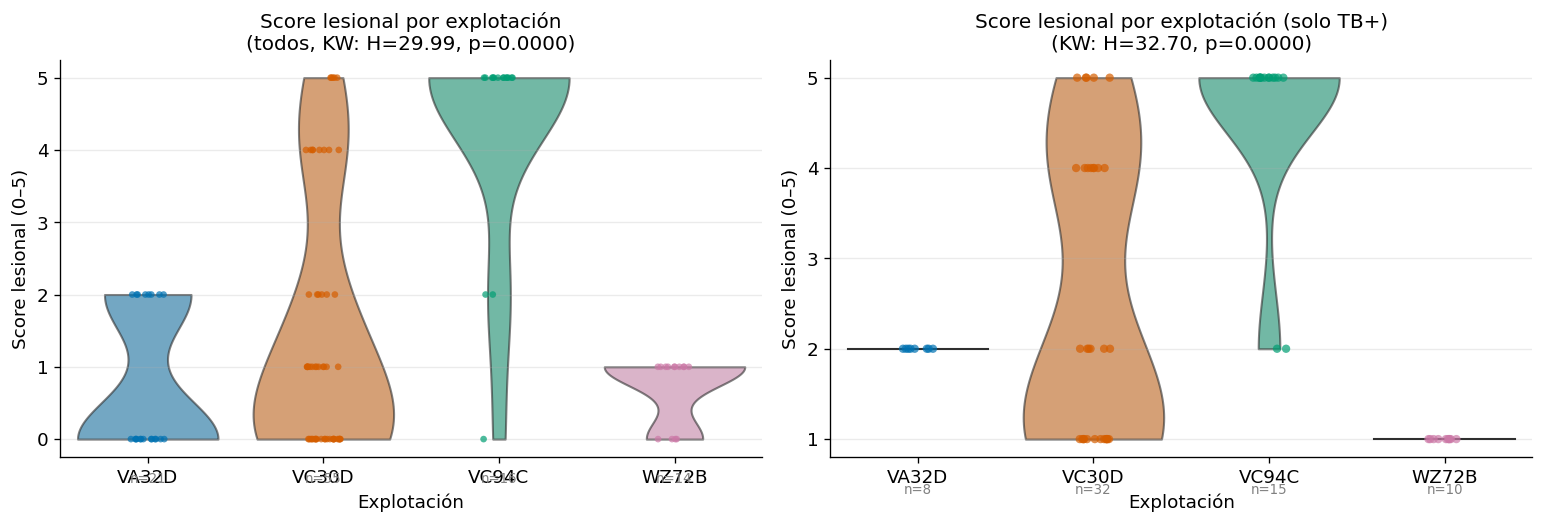

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Violin + strip — todos los animales
ax = axes[0]
sns.violinplot(data=df, x=tb.GROUP_COL, y="Score_lesional", order=EXPLOTS,
               palette=EXPL_COLORS, inner=None, ax=ax, alpha=0.6, cut=0)
sns.stripplot(data=df, x=tb.GROUP_COL, y="Score_lesional", order=EXPLOTS,
              palette=EXPL_COLORS, jitter=True, alpha=0.7, size=4, ax=ax)
ax.set_title(f"Score lesional por explotación\n(todos, KW: H={H:.2f}, p={p_kw:.4f})")
ax.set_xlabel("Explotación"); ax.set_ylabel("Score lesional (0–5)")
ax.set_yticks(range(6))

# Solo TB+ para aislar gravedad
df_pos = df[df["Lesiones_TB"] == 1].copy()
groups_pos = [df_pos[df_pos[tb.GROUP_COL] == g]["Score_lesional"].dropna().values for g in EXPLOTS]
# Excluir grupos con menos de 2 observaciones
valid_explots = [g for g, gr in zip(EXPLOTS, groups_pos) if len(gr) >= 2]
valid_groups  = [gr for gr in groups_pos if len(gr) >= 2]
if len(valid_groups) >= 2:
    H_pos, p_pos = kruskal(*valid_groups)
    title_pos = f"Score lesional por explotación (solo TB+)\n(KW: H={H_pos:.2f}, p={p_pos:.4f})"
else:
    H_pos, p_pos = None, None
    title_pos = "Score lesional por explotación (solo TB+)"

ax2 = axes[1]
sns.violinplot(data=df_pos, x=tb.GROUP_COL, y="Score_lesional", order=EXPLOTS,
               palette=EXPL_COLORS, inner=None, ax=ax2, alpha=0.6, cut=0)
sns.stripplot(data=df_pos, x=tb.GROUP_COL, y="Score_lesional", order=EXPLOTS,
              palette=EXPL_COLORS, jitter=True, alpha=0.7, size=5, ax=ax2)
ax2.set_title(title_pos)
ax2.set_xlabel("Explotación"); ax2.set_ylabel("Score lesional (0–5)")
ax2.set_yticks(range(1, 6))

# Anotar n por grupo en ambos paneles
for i, granja in enumerate(EXPLOTS):
    n_all = (df[tb.GROUP_COL] == granja).sum()
    n_pos2 = (df_pos[tb.GROUP_COL] == granja).sum()
    axes[0].text(i, -0.6, f"n={n_all}", ha="center", fontsize=8, color="grey")
    axes[1].text(i, 0.4, f"n={n_pos2}", ha="center", fontsize=8, color="grey")

plt.tight_layout()
plt.savefig("figures/fig_05_score_lesional_por_explotacion.png", dpi=150, bbox_inches="tight")
plt.show()

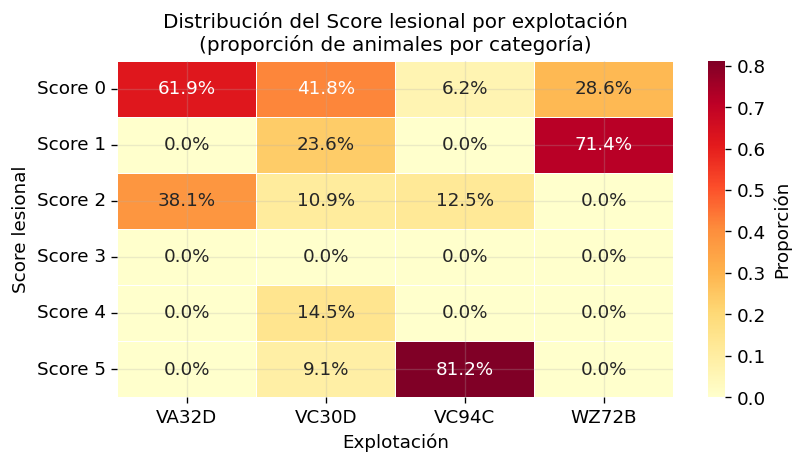

In [10]:
# Distribución de frecuencias del score por explotación (heatmap de proporciones)
scores_all = range(0, 6)
heat_data = pd.DataFrame(
    {granja: [round((df[df[tb.GROUP_COL] == granja]["Score_lesional"] == s).mean(), 3)
              for s in scores_all]
     for granja in EXPLOTS},
    index=[f"Score {s}" for s in scores_all]
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(heat_data, annot=True, fmt=".1%", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Proporción"})
ax.set_title("Distribución del Score lesional por explotación\n(proporción de animales por categoría)")
ax.set_ylabel("Score lesional"); ax.set_xlabel("Explotación")
plt.tight_layout()
plt.savefig("figures/fig_05_score_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Patrón de lesiones (generalizado vs focal) por explotación

Análisis restringido a animales **TB+** (n con lesión).
`Patron_lesiones`: 0 = lesión focal (nodal única), 1 = lesión generalizada (patrón extendido).

Se usa test exacto de Fisher (o chi-cuadrado si los esperados lo permiten) dado el
número reducido de animales con lesión en algunas explotaciones.

In [11]:
df_pat = df[df["Lesiones_TB"] == 1].copy()

# Tabla de contingencia Expl × Patron_lesiones
cont_pat = pd.crosstab(df_pat[tb.GROUP_COL], df_pat["Patron_lesiones"])
cont_pat.columns = ["Focal (0)", "Generalizado (1)"]
print("Tabla de contingencia Expl × Patrón de lesiones (solo TB+):")
display(cont_pat)

# Test global
chi2_pat, p_chi2_pat, dof_pat, exp_pat = chi2_contingency(cont_pat)
min_exp_pat = exp_pat.min()
print(f"\nChi-cuadrado: χ²({dof_pat}) = {chi2_pat:.3f}, p = {p_chi2_pat:.4f}")
print(f"Frecuencia esperada mínima: {min_exp_pat:.2f}")
if min_exp_pat < 5:
    print("⚠ Esperados < 5 en alguna celda — se recomienda usar Fisher exacto (ver comparaciones pareadas).")

# Proporciones de patrón generalizado por explotación
print("\nProporción patrón generalizado por explotación (entre TB+):")
for granja in EXPLOTS:
    g = df_pat[df_pat[tb.GROUP_COL] == granja]
    n_g = len(g)
    n_gen = int((g["Patron_lesiones"] == 1).sum())
    if n_g > 0:
        lo, hi = proportion_confint(n_gen, n_g, alpha=0.05, method="wilson")
        print(f"  {granja}: {n_gen}/{n_g} = {n_gen/n_g:.1%} [IC95%: {lo:.1%}–{hi:.1%}]")
    else:
        print(f"  {granja}: sin datos TB+")

Tabla de contingencia Expl × Patrón de lesiones (solo TB+):


,Focal (0),Generalizado (1)
Expl,,
VA32D,5,3
VC30D,24,8
VC94C,2,13
WZ72B,10,0



Chi-cuadrado: χ²(3) = 23.745, p = 0.0000
Frecuencia esperada mínima: 2.95
⚠ Esperados < 5 en alguna celda — se recomienda usar Fisher exacto (ver comparaciones pareadas).

Proporción patrón generalizado por explotación (entre TB+):
  VA32D: 3/8 = 37.5% [IC95%: 13.7%–69.4%]
  VC30D: 8/32 = 25.0% [IC95%: 13.3%–42.1%]
  VC94C: 13/15 = 86.7% [IC95%: 62.1%–96.3%]
  WZ72B: 0/10 = 0.0% [IC95%: 0.0%–27.8%]


In [12]:
# Comparaciones pareadas con Fisher exacto (solo pares con datos en ambas clases)
pat_pairs = []
for a, b in combinations(EXPLOTS, 2):
    sub = df_pat[df_pat[tb.GROUP_COL].isin([a, b])]
    ct = pd.crosstab(sub[tb.GROUP_COL], sub["Patron_lesiones"]).reindex([a, b])
    for col in [0, 1]:
        if col not in ct.columns:
            ct[col] = 0
    ct = ct[[0, 1]]
    if ct.shape == (2, 2) and ct.values.sum() >= 4:
        _, p = fisher_exact(ct.values)
        p_bonf = min(p * n_pairs, 1.0)
        n_a = (df_pat[tb.GROUP_COL] == a).sum()
        n_b = (df_pat[tb.GROUP_COL] == b).sum()
        prop_a = (df_pat[df_pat[tb.GROUP_COL] == a]["Patron_lesiones"] == 1).mean()
        prop_b = (df_pat[df_pat[tb.GROUP_COL] == b]["Patron_lesiones"] == 1).mean()
        pat_pairs.append({
            "Expl A": f"{a} ({n_a})", "% Gen. A": f"{prop_a:.1%}",
            "Expl B": f"{b} ({n_b})", "% Gen. B": f"{prop_b:.1%}",
            "p (Fisher)": round(p, 4),
            "p (Bonferroni)": round(p_bonf, 4),
            "Sig.": "*" if p_bonf < 0.05 else "",
        })

if pat_pairs:
    print("Comparaciones pareadas — Patrón generalizado:")
    display(pd.DataFrame(pat_pairs))

Comparaciones pareadas — Patrón generalizado:


,Expl A,% Gen. A,Expl B,% Gen. B,p (Fisher),p (Bonferroni),Sig.
0,VA32D (8),37.5%,VC30D (32),25.0%,0.6603,1.0000,
1,VA32D (8),37.5%,VC94C (15),86.7%,0.0257,0.1544,
2,VA32D (8),37.5%,WZ72B (10),0.0%,0.0686,0.4118,
3,VC30D (32),25.0%,VC94C (15),86.7%,0.0001,0.0006,*
4,VC30D (32),25.0%,WZ72B (10),0.0%,0.1646,0.9876,
5,VC94C (15),86.7%,WZ72B (10),0.0%,0.0000,0.0001,*


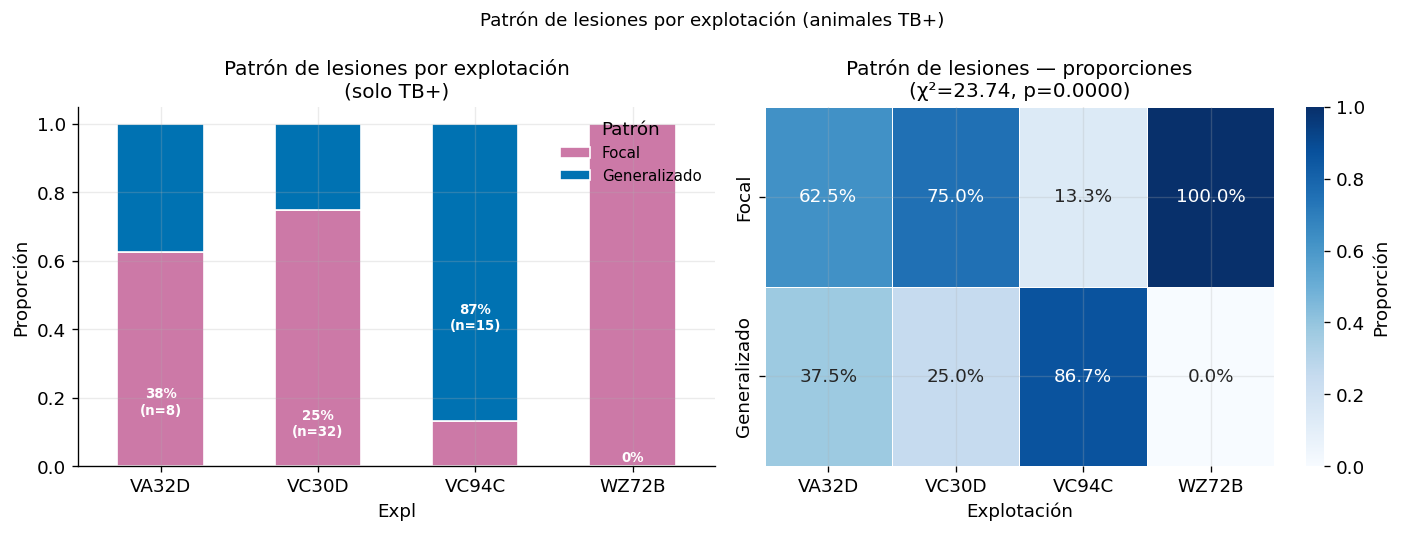

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Barras apiladas proporcionales (patrón)
pat_prop = cont_pat.div(cont_pat.sum(axis=1), axis=0)
ax = axes[0]
pat_prop.plot(kind="bar", stacked=True, ax=ax,
              color=[PALETTE[3], PALETTE[0]], edgecolor="white", width=0.55)
ax.set_ylabel("Proporción")
ax.set_title("Patrón de lesiones por explotación\n(solo TB+)")
ax.set_xticklabels(EXPLOTS, rotation=0)
ax.legend(["Focal", "Generalizado"], title="Patrón", fontsize=9)
for i, granja in enumerate(EXPLOTS):
    if granja in pat_prop.index:
        p_gen = pat_prop.loc[granja, "Generalizado (1)"] if "Generalizado (1)" in pat_prop.columns else 0
        n_gr = cont_pat.loc[granja].sum() if granja in cont_pat.index else 0
        ax.text(i, p_gen / 2, f"{p_gen:.0%}\n(n={int(n_gr)})",
                ha="center", va="center", fontsize=8, color="white", fontweight="bold")

# Heatmap de proporciones
ax2 = axes[1]
heat_pat = pd.DataFrame({
    granja: [
        round((df_pat[df_pat[tb.GROUP_COL] == granja]["Patron_lesiones"] == 0).mean(), 3),
        round((df_pat[df_pat[tb.GROUP_COL] == granja]["Patron_lesiones"] == 1).mean(), 3)
    ]
    for granja in EXPLOTS
}, index=["Focal", "Generalizado"])
sns.heatmap(heat_pat, annot=True, fmt=".1%", cmap="Blues",
            linewidths=0.5, ax=ax2, cbar_kws={"label": "Proporción"},
            vmin=0, vmax=1)
ax2.set_title(f"Patrón de lesiones — proporciones\n(χ²={chi2_pat:.2f}, p={p_chi2_pat:.4f})")
ax2.set_xlabel("Explotación")

plt.suptitle("Patrón de lesiones por explotación (animales TB+)", fontsize=11)
plt.tight_layout()
plt.savefig("figures/fig_05_patron_lesiones_por_explotacion.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. IDTC por explotación

La intensidad de la reacción IDTC (intradermotuberculinización comparada) es una
variable continua ≥ 0. Se compara entre explotaciones con Kruskal-Wallis y se analiza
si su distribución varía entre animales TB+ y TB− dentro de cada explotación.

In [14]:
# Descriptivos IDTC por explotación
idtc_desc = df.groupby(tb.GROUP_COL)["IDTC"].describe(
    percentiles=[0.25, 0.5, 0.75]
).round(2)
print("Descriptivos IDTC por explotación:")
display(idtc_desc)

groups_idtc = [df[df[tb.GROUP_COL] == g]["IDTC"].dropna().values for g in EXPLOTS]
H_idtc, p_idtc = kruskal(*groups_idtc)
print(f"\nKruskal-Wallis (IDTC ~ Explotación): H = {H_idtc:.3f}, p = {p_idtc:.4f}")

# Comparaciones pareadas
idtc_pw = []
for a, b in combinations(EXPLOTS, 2):
    g_a = df[df[tb.GROUP_COL] == a]["IDTC"].dropna().values
    g_b = df[df[tb.GROUP_COL] == b]["IDTC"].dropna().values
    _, p_mw = mannwhitneyu(g_a, g_b, alternative="two-sided")
    p_bonf = min(p_mw * n_pairs, 1.0)
    idtc_pw.append({
        "Expl A": a, "Med A": round(np.median(g_a), 1),
        "Expl B": b, "Med B": round(np.median(g_b), 1),
        "p (MW)": round(p_mw, 4),
        "p (Bonferroni)": round(p_bonf, 4),
        "Sig.": "*" if p_bonf < 0.05 else "",
    })
print("\nComparaciones pareadas IDTC:")
display(pd.DataFrame(idtc_pw))

Descriptivos IDTC por explotación:


,count,mean,std,min,25%,50%,75%,max
Expl,,,,,,,,
VA32D,21.0,14.00,6.63,7.0,10.0,13.0,17.00,32.0
VC30D,55.0,11.25,5.90,5.0,6.0,10.0,13.50,26.0
VC94C,16.0,8.56,4.73,5.0,5.0,7.0,10.25,23.0
WZ72B,14.0,12.43,6.61,0.0,9.0,11.5,14.00,27.0



Kruskal-Wallis (IDTC ~ Explotación): H = 11.548, p = 0.0091

Comparaciones pareadas IDTC:


,Expl A,Med A,Expl B,Med B,p (MW),p (Bonferroni),Sig.
0,VA32D,13.0,VC30D,10.0,0.0402,0.2412,
1,VA32D,13.0,VC94C,7.0,0.0020,0.0118,*
2,VA32D,13.0,WZ72B,11.5,0.6244,1.0000,
3,VC30D,10.0,VC94C,7.0,0.0420,0.2518,
4,VC30D,10.0,WZ72B,11.5,0.2676,1.0000,
5,VC94C,7.0,WZ72B,11.5,0.0281,0.1686,


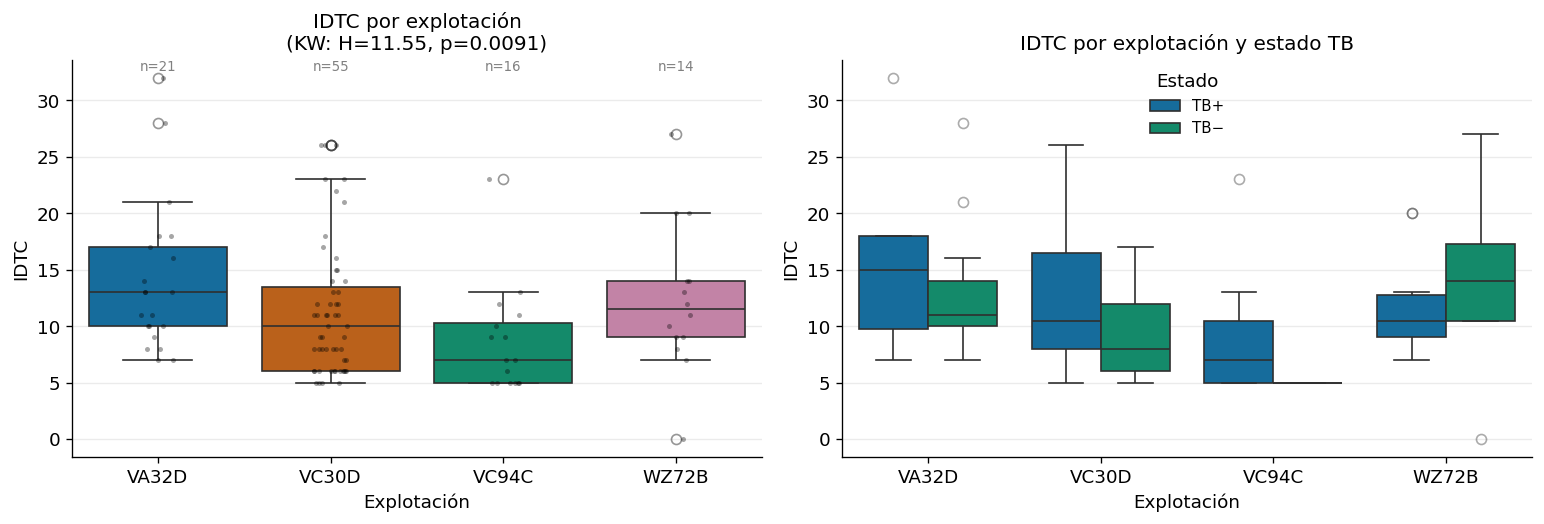

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Boxplot IDTC por explotación
ax = axes[0]
sns.boxplot(data=df, x=tb.GROUP_COL, y="IDTC", order=EXPLOTS,
            palette=EXPL_COLORS, ax=ax, flierprops=dict(alpha=0.5))
sns.stripplot(data=df, x=tb.GROUP_COL, y="IDTC", order=EXPLOTS,
              color="black", alpha=0.35, size=3, ax=ax, jitter=True)
ax.set_title(f"IDTC por explotación\n(KW: H={H_idtc:.2f}, p={p_idtc:.4f})")
ax.set_xlabel("Explotación"); ax.set_ylabel("IDTC")
for i, granja in enumerate(EXPLOTS):
    n = (df[tb.GROUP_COL] == granja).sum()
    ax.text(i, df["IDTC"].max() * 1.02, f"n={n}", ha="center", fontsize=8, color="grey")

# IDTC separado por estado TB
ax2 = axes[1]
df_plot = df.copy()
df_plot["Estado"] = df_plot["Lesiones_TB"].map({0: "TB−", 1: "TB+"})
sns.boxplot(data=df_plot, x=tb.GROUP_COL, y="IDTC", hue="Estado",
            order=EXPLOTS, palette={"TB−": PALETTE[2], "TB+": PALETTE[0]},
            ax=ax2, flierprops=dict(alpha=0.4))
ax2.set_title("IDTC por explotación y estado TB")
ax2.set_xlabel("Explotación"); ax2.set_ylabel("IDTC")
ax2.legend(title="Estado", fontsize=9)

plt.tight_layout()
plt.savefig("figures/fig_05_idtc_por_explotacion.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Biomarcadores (VitD, Calcio, serología) por explotación

Se comparan los biomarcadores entre explotaciones para entender si las diferencias
en prevalencia de lesiones podrían estar mediadas por diferencias en los perfiles
biológicos de los animales de cada granja.

> Esto es descriptivo-exploratorio: **no implica causalidad** ni se ajustan confusores.

In [16]:
BIOM_CONT = ["VITAMINA_D", "CALCIO", "PIROPLASMA_Q", "EDAD"]
BIOM_BIN  = ["PIROPLASMA", "THEILERIA", "ANAPLASMA"]

# Kruskal-Wallis para cada biomarcador continuo
print("Kruskal-Wallis: biomarcadores continuos ~ Explotación\n")
kw_results = []
for var in BIOM_CONT:
    groups_v = [df[df[tb.GROUP_COL] == g][var].dropna().values for g in EXPLOTS]
    if all(len(g) >= 2 for g in groups_v):
        H_v, p_v = kruskal(*groups_v)
        sig = "*" if p_v < 0.05 else ""
        kw_results.append({"Variable": tb.PRETTY.get(var, var), "H": round(H_v, 3), "p": round(p_v, 4), "Sig.": sig})
        print(f"  {tb.PRETTY.get(var, var):35s}: H={H_v:.3f}, p={p_v:.4f} {sig}")

# Chi-cuadrado para biomarcadores binarios
print("\nChi-cuadrado: biomarcadores binarios ~ Explotación\n")
for var in BIOM_BIN:
    ct = pd.crosstab(df[tb.GROUP_COL], df[var].dropna())
    if ct.shape == (len(EXPLOTS), 2):
        chi2_v, p_v, _, _ = chi2_contingency(ct)
        sig = "*" if p_v < 0.05 else ""
        print(f"  {tb.PRETTY.get(var, var):35s}: χ²={chi2_v:.3f}, p={p_v:.4f} {sig}")

Kruskal-Wallis: biomarcadores continuos ~ Explotación

  Vitamina D                         : H=21.399, p=0.0001 *
  Calcio                             : H=10.635, p=0.0139 *
  Carga piroplasma (q)               : H=29.546, p=0.0000 *
  Edad (años)                        : H=10.864, p=0.0125 *

Chi-cuadrado: biomarcadores binarios ~ Explotación

  Piroplasma (+)                     : χ²=30.543, p=0.0000 *
  Theileria spp. (+)                 : χ²=26.534, p=0.0000 *
  Anaplasma spp. (+)                 : χ²=31.091, p=0.0000 *


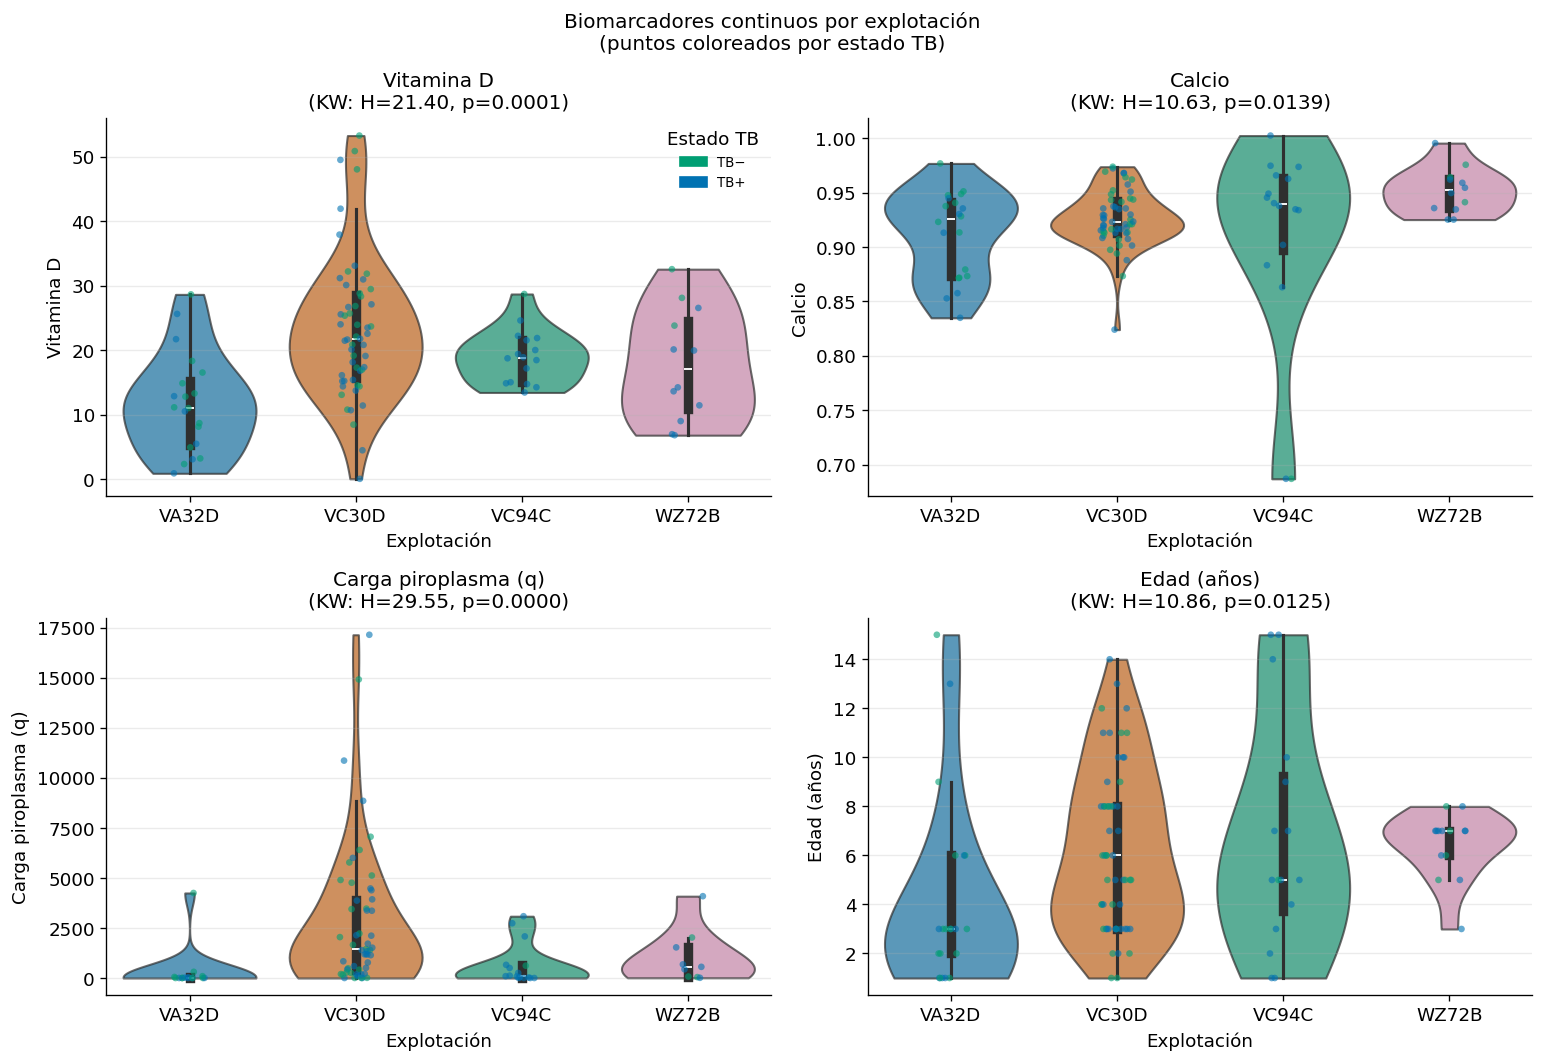

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, var in zip(axes.flat, BIOM_CONT):
    g_data = [df[df[tb.GROUP_COL] == g][var].dropna().values for g in EXPLOTS]
    H_v, p_v = kruskal(*[g for g in g_data if len(g) >= 2])
    
    sns.violinplot(data=df, x=tb.GROUP_COL, y=var, order=EXPLOTS,
                   palette=EXPL_COLORS, inner="box", ax=ax, alpha=0.7, cut=0)
    sns.stripplot(data=df, x=tb.GROUP_COL, y=var, hue="Lesiones_TB", order=EXPLOTS,
                  palette={0: PALETTE[2], 1: PALETTE[0]}, jitter=True,
                  alpha=0.6, size=4, ax=ax, legend=ax == axes.flat[0])
    ax.set_title(f"{tb.PRETTY.get(var, var)}\n(KW: H={H_v:.2f}, p={p_v:.4f})")
    ax.set_xlabel("Explotación"); ax.set_ylabel(tb.PRETTY.get(var, var))
    
    # Leyenda solo en primer panel
    if ax == axes.flat[0]:
        handles = [
            mpatches.Patch(color=PALETTE[2], label="TB−"),
            mpatches.Patch(color=PALETTE[0], label="TB+")
        ]
        ax.legend(handles=handles, title="Estado TB", fontsize=8, loc="upper right")

plt.suptitle("Biomarcadores continuos por explotación\n(puntos coloreados por estado TB)",
             fontsize=12)
plt.tight_layout()
plt.savefig("figures/fig_05_biomarkers_por_explotacion.png", dpi=150, bbox_inches="tight")
plt.show()

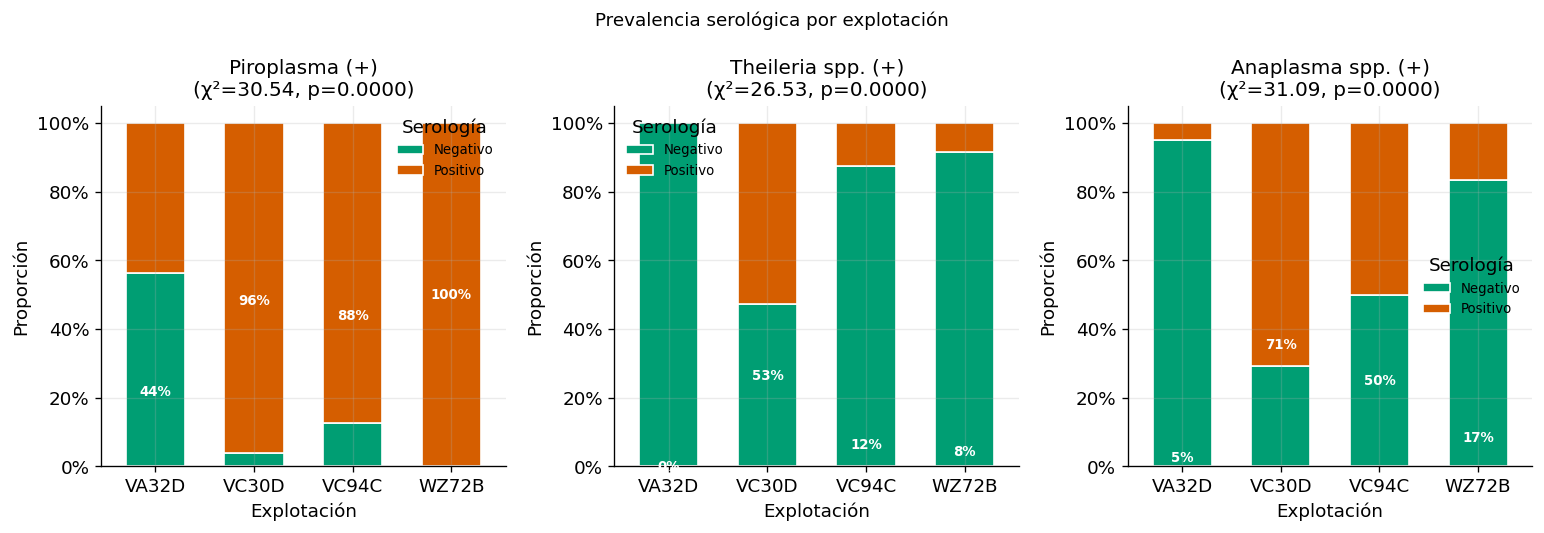

In [18]:
# Serología por explotación
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, var in zip(axes, BIOM_BIN):
    ct = pd.crosstab(df[tb.GROUP_COL], df[var])
    ct.columns = ["Neg.", "Pos."]
    prop = ct.div(ct.sum(axis=1), axis=0)
    prop.plot(kind="bar", stacked=True, ax=ax,
              color=[PALETTE[2], PALETTE[1]], edgecolor="white", width=0.6)
    chi2_v, p_v, _, _ = chi2_contingency(ct)
    ax.set_title(f"{tb.PRETTY.get(var, var)}\n(χ²={chi2_v:.2f}, p={p_v:.4f})")
    ax.set_xlabel("Explotación"); ax.set_ylabel("Proporción")
    ax.set_xticklabels(EXPLOTS, rotation=0)
    ax.legend(["Negativo", "Positivo"], fontsize=8, title="Serología")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    for i, granja in enumerate(EXPLOTS):
        p_pos = prop.loc[granja, "Pos."] if granja in prop.index else 0
        ax.text(i, p_pos / 2, f"{p_pos:.0%}", ha="center", va="center",
                fontsize=8, color="white", fontweight="bold")

plt.suptitle("Prevalencia serológica por explotación", fontsize=11)
plt.tight_layout()
plt.savefig("figures/fig_05_serologia_por_explotacion.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Relación Score lesional — biomarcadores, estratificado por explotación

Correlaciones de Spearman entre Score lesional y cada biomarcador continuo,
calculadas dentro de cada explotación y en el conjunto global.

In [19]:
corr_rows = []
for granja in ["GLOBAL"] + EXPLOTS:
    sub = df if granja == "GLOBAL" else df[df[tb.GROUP_COL] == granja]
    for var in BIOM_CONT:
        valid = sub[[var, "Score_lesional"]].dropna()
        if len(valid) >= 5:
            rho, p_rho = spearmanr(valid[var], valid["Score_lesional"])
            sig = "*" if p_rho < 0.05 else ""
            corr_rows.append({
                "Explotación": granja, "Variable": tb.PRETTY.get(var, var),
                "ρ (Spearman)": round(rho, 3), "p": round(p_rho, 4),
                "n": len(valid), "Sig.": sig
            })

corr_df = pd.DataFrame(corr_rows)
print("Correlaciones Spearman: biomarcador ~ Score lesional, por explotación:")
display(corr_df.pivot_table(
    index="Variable", columns="Explotación", values="ρ (Spearman)"
).round(3))

Correlaciones Spearman: biomarcador ~ Score lesional, por explotación:


Explotación,GLOBAL,VA32D,VC30D,VC94C,WZ72B
Variable,,,,,
Calcio,0.011,-0.336,0.005,0.175,-0.363
Carga piroplasma (q),-0.138,-0.154,-0.129,-0.396,0.183
Edad (años),0.128,-0.100,0.160,-0.075,0.021
Vitamina D,-0.079,-0.082,-0.167,-0.551,-0.697


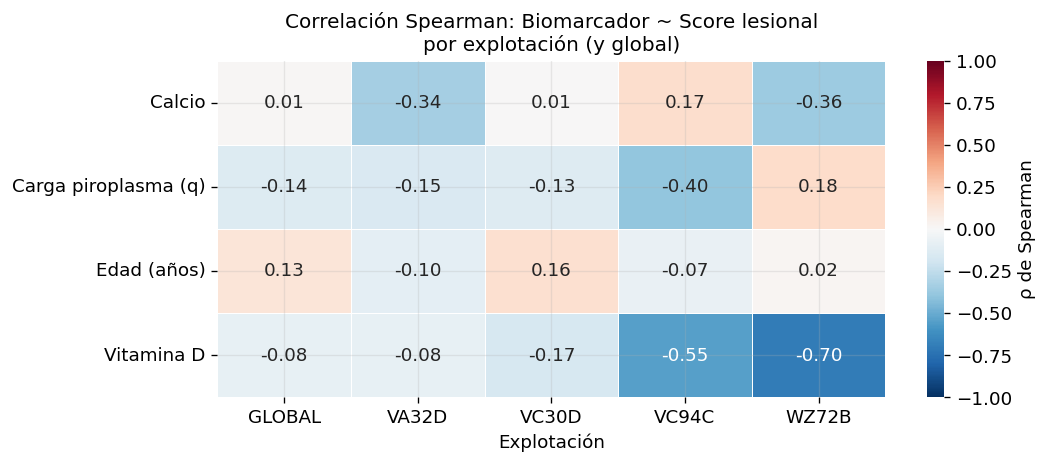

In [20]:
heat_corr = corr_df.pivot_table(
    index="Variable", columns="Explotación", values="ρ (Spearman)"
).round(3)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(heat_corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={"label": "ρ de Spearman"})
ax.set_title("Correlación Spearman: Biomarcador ~ Score lesional\npor explotación (y global)")
ax.set_xlabel("Explotación"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig("figures/fig_05_spearman_score_biomarkers.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Tabla resumen consolidada

In [21]:
print("=" * 70)
print("TABLA RESUMEN COMPLETA POR EXPLOTACIÓN")
print("=" * 70)

summary_rows = []
for granja in EXPLOTS:
    g     = df[df[tb.GROUP_COL] == granja]
    g_pos = g[g["Lesiones_TB"] == 1]
    n     = len(g)
    n_pos = int(g["Lesiones_TB"].sum())
    prev  = n_pos / n
    lo, hi = proportion_confint(n_pos, n, alpha=0.05, method="wilson")

    # Score lesional
    sl_med  = g["Score_lesional"].median()
    sl_iqr  = g["Score_lesional"].quantile([0.25, 0.75]).values

    # Patrón (solo TB+)
    n_gen = int((g_pos["Patron_lesiones"] == 1).sum()) if len(g_pos) > 0 else 0
    p_gen = f"{n_gen}/{n_pos} ({n_gen/n_pos:.0%})" if n_pos > 0 else "—"

    # IDTC
    idtc_med = g["IDTC"].median()
    idtc_iqr = g["IDTC"].quantile([0.25, 0.75]).values

    # VitD
    vd_med = g["VITAMINA_D"].median()
    vd_iqr = g["VITAMINA_D"].quantile([0.25, 0.75]).values

    summary_rows.append({
        "Explotación": granja,
        "n": n,
        "TB+ (n)": n_pos,
        "Prevalencia [IC95%]": f"{prev:.1%} [{lo:.1%}–{hi:.1%}]",
        "Score med [IQR]": f"{sl_med:.1f} [{sl_iqr[0]:.1f}–{sl_iqr[1]:.1f}]",
        "Patrón gen. (entre TB+)": p_gen,
        "IDTC med [IQR]": f"{idtc_med:.1f} [{idtc_iqr[0]:.1f}–{idtc_iqr[1]:.1f}]",
        "VitD med [IQR]": f"{vd_med:.1f} [{vd_iqr[0]:.1f}–{vd_iqr[1]:.1f}]",
    })

# Añadir fila global
g = df
g_pos = df[df["Lesiones_TB"] == 1]
n = len(g); n_pos = int(g["Lesiones_TB"].sum()); prev = n_pos / n
lo, hi = proportion_confint(n_pos, n, alpha=0.05, method="wilson")
sl_med = g["Score_lesional"].median(); sl_iqr = g["Score_lesional"].quantile([0.25, 0.75]).values
n_gen  = int((g_pos["Patron_lesiones"] == 1).sum())
p_gen  = f"{n_gen}/{n_pos} ({n_gen/n_pos:.0%})"
idtc_med = g["IDTC"].median(); idtc_iqr = g["IDTC"].quantile([0.25, 0.75]).values
vd_med   = g["VITAMINA_D"].median(); vd_iqr = g["VITAMINA_D"].quantile([0.25, 0.75]).values
summary_rows.append({
    "Explotación": "GLOBAL",
    "n": n, "TB+ (n)": n_pos,
    "Prevalencia [IC95%]": f"{prev:.1%} [{lo:.1%}–{hi:.1%}]",
    "Score med [IQR]": f"{sl_med:.1f} [{sl_iqr[0]:.1f}–{sl_iqr[1]:.1f}]",
    "Patrón gen. (entre TB+)": p_gen,
    "IDTC med [IQR]": f"{idtc_med:.1f} [{idtc_iqr[0]:.1f}–{idtc_iqr[1]:.1f}]",
    "VitD med [IQR]": f"{vd_med:.1f} [{vd_iqr[0]:.1f}–{vd_iqr[1]:.1f}]",
})

summ_df = pd.DataFrame(summary_rows)
display(summ_df)

print("\n--- Tests estadísticos globales ---")
print(f"Lesiones_TB ~ Expl:    χ²({dof}) = {chi2:.3f}, p = {p_chi2:.4f}")
print(f"Score lesional ~ Expl: H = {H:.3f}, p = {p_kw:.4f}")
print(f"Patrón ~ Expl (TB+):   χ²({dof_pat}) = {chi2_pat:.3f}, p = {p_chi2_pat:.4f}")
print(f"IDTC ~ Expl:           H = {H_idtc:.3f}, p = {p_idtc:.4f}")

TABLA RESUMEN COMPLETA POR EXPLOTACIÓN


,Explotación,n,TB+ (n),Prevalencia [IC95%],Score med [IQR],Patrón gen. (entre TB+),IDTC med [IQR],VitD med [IQR]
0,VA32D,21,8,38.1% [20.8%–59.1%],0.0 [0.0–2.0],3/8 (38%),13.0 [10.0–17.0],11.1 [5.4–15.3]
1,VC30D,55,32,58.2% [45.0%–70.3%],1.0 [0.0–2.0],8/32 (25%),10.0 [6.0–13.5],21.8 [15.8–28.6]
2,VC94C,16,15,93.8% [71.7%–98.9%],5.0 [5.0–5.0],13/15 (87%),7.0 [5.0–10.2],18.8 [15.0–21.6]
3,WZ72B,14,10,71.4% [45.4%–88.3%],1.0 [0.2–1.0],0/10 (0%),11.5 [9.0–14.0],17.1 [10.9–24.5]
4,GLOBAL,106,65,61.3% [51.8%–70.0%],1.0 [0.0–2.0],24/65 (37%),10.0 [7.0–14.0],18.9 [13.5–25.5]



--- Tests estadísticos globales ---
Lesiones_TB ~ Expl:    χ²(3) = 12.702, p = 0.0053
Score lesional ~ Expl: H = 29.988, p = 0.0000
Patrón ~ Expl (TB+):   χ²(3) = 23.745, p = 0.0000
IDTC ~ Expl:           H = 11.548, p = 0.0091


## 10. Conclusiones descriptivas

*(Completar con los resultados obtenidos al ejecutar el notebook)*

### Prevalencia de lesiones
- Indicar si las prevalencias difieren significativamente entre explotaciones
  (resultado del test chi-cuadrado global y pares significativos).
- Señalar qué explotación muestra mayor/menor prevalencia y su IC 95%.

### Gravedad (Score lesional)
- Indicar si el score lesional difiere entre explotaciones (Kruskal-Wallis).
- Señalar qué pares son significativos tras corrección de Bonferroni.
- Distinguir si la diferencia persiste cuando el análisis se restringe a TB+
  (efecto sobre la gravedad, no solo sobre la prevalencia).

### Patrón de lesiones
- Indicar si la proporción de patrón generalizado vs focal varía entre explotaciones.

### IDTC
- Indicar si hay variación significativa entre explotaciones.

### Perfil de biomarcadores
- Señalar qué biomarcadores difieren significativamente por explotación.
- Comentar si la variación en VitD o calcio podría explicar parte de las diferencias
  de prevalencia (exploratoriamente; no implica causalidad).

---
> **Limitaciones:**
> - El diseño es transversal y observacional. Las diferencias entre explotaciones
>   pueden deberse a factores estructurales (tamaño del rebaño, manejo, contacto
>   fauna silvestre) no recogidos en los datos.
> - El tamaño de algunas explotaciones (n=14–16) limita la potencia estadística.
> - Las comparaciones pareadas no controlan cofactores como edad o raza.